In [1]:
import os
from pathlib import Path

# Anchor to the repo root regardless of where the notebook is launched from,
# so this runs unchanged on any machine.
if Path("data/raw").exists():
    ROOT = Path.cwd()
else:
    ROOT = Path.cwd().parent
os.chdir(ROOT)
print(ROOT)

c:\Users\USER\csbc_business_conditions_analysis


In [2]:
import pandas as pd

df = pd.read_csv("data/raw/Data CSBC-Q1 2024.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(2352, 6)


,GEO,Business_characteristics,Business_information,Expected_change,VALUE,Quarter
0,Canada,North American Industry Classification System ...,Employment,increase,11.1,Q1 2024
1,Canada,North American Industry Classification System ...,Employment,stay about the same,82.9,Q1 2024
2,Canada,North American Industry Classification System ...,Employment,decrease,6.0,Q1 2024
3,Canada,North American Industry Classification System ...,Sales,increase,17.8,Q1 2024
4,Canada,North American Industry Classification System ...,Sales,stay about the same,63.1,Q1 2024


In [3]:
import glob

paths = sorted(glob.glob("data/raw/*.csv"))
print(paths)

frames = [pd.read_csv(p, encoding="utf-8-sig") for p in paths]
all_q = pd.concat(frames, ignore_index=True)
print(all_q.shape)

print(all_q["Quarter"].value_counts())

['data/raw\\Data CSBC-Q1 2024.csv', 'data/raw\\Data CSBC-Q2 2024.csv', 'data/raw\\Data CSBC-Q3 2023.csv', 'data/raw\\Data CSBC-Q4 2023.csv']
(9408, 6)
Quarter
Q1 2024    2352
Q2 2024    2352
Q3 2023    2352
Q4 2023    2352
Name: count, dtype: int64


In [4]:
pd.crosstab(all_q["Quarter"], all_q["Expected_change"])

Expected_change,decrease,increase,stay about the same,stay the same
Quarter,,,,
Q1 2024,784,784,784,0
Q2 2024,784,784,0,784
Q3 2023,784,784,784,0
Q4 2023,784,784,784,0


In [5]:
print(all_q.groupby("Quarter")["GEO"].nunique())
print(all_q.groupby("Quarter")["Business_characteristics"].nunique())

Quarter
Q1 2024    14
Q2 2024    14
Q3 2023    14
Q4 2023    14
Name: GEO, dtype: int64
Quarter
Q1 2024    14
Q2 2024    14
Q3 2023    14
Q4 2023    14
Name: Business_characteristics, dtype: int64


In [6]:
pd.crosstab(all_q["Quarter"], all_q["Business_information"])

Business_information,Capital Investment,Employment,Investment,Profitability,Sales
Quarter,,,,,
Q1 2024,0,588,588,588,588
Q2 2024,588,588,0,588,588
Q3 2023,0,588,588,588,588
Q4 2023,0,588,588,588,588


In [7]:
DIRECTION_ALIASES = {
    "increase": "increase",
    "stay about the same": "stay about the same",
    "stay the same": "stay about the same",
    "decrease": "decrease",
}

METRIC_ALIASES = {
    "employment": "Employment",
    "sales": "Sales",
    "profitability": "Profitability",
    "investment": "Investment",
    "capital investment": "Investment",
}

all_q["direction"] = all_q["Expected_change"].str.strip().str.lower().map(DIRECTION_ALIASES)
all_q["metric"] = all_q["Business_information"].str.strip().str.lower().map(METRIC_ALIASES)

print(all_q["direction"].isna().sum(), "unmapped directions")
print(all_q["metric"].isna().sum(), "unmapped metrics")

pd.crosstab(all_q["Quarter"], all_q["direction"])

0 unmapped directions
0 unmapped metrics


direction,decrease,increase,stay about the same
Quarter,,,
Q1 2024,784,784,784
Q2 2024,784,784,784
Q3 2023,784,784,784
Q4 2023,784,784,784


In [8]:
print(all_q["VALUE"].dtype)
print(all_q["VALUE"].describe())
print("missing:", all_q["VALUE"].isna().sum())
print("zeros:", (all_q["VALUE"] == 0).sum())

float64
count    9401.000000
mean       29.348165
std        27.819742
min         0.000000
25%         7.500000
50%        17.600000
75%        53.200000
max       100.000000
Name: VALUE, dtype: float64
missing: 7
zeros: 1043


In [9]:
all_q[all_q["VALUE"].isna()][["GEO", "Business_characteristics", "metric", "direction", "Quarter"]]

,GEO,Business_characteristics,metric,direction,Quarter
2354,Canada,North American Industry Classification System ...,Employment,decrease,Q2 2024
2357,Canada,North American Industry Classification System ...,Sales,decrease,Q2 2024
2360,Canada,North American Industry Classification System ...,Profitability,decrease,Q2 2024
2363,Canada,North American Industry Classification System ...,Investment,decrease,Q2 2024
2365,Canada,"Agriculture, forestry, fishing and hunting",Employment,stay about the same,Q2 2024
2366,Canada,"Agriculture, forestry, fishing and hunting",Employment,decrease,Q2 2024
2369,Canada,"Agriculture, forestry, fishing and hunting",Sales,decrease,Q2 2024


In [10]:
zeros = all_q[all_q["VALUE"] == 0]
print(zeros.groupby("GEO").size().sort_values(ascending=False))

GEO
Nunavut                      334
Northwest Territories        316
Yukon                        303
Prince Edward Island          51
New Brunswick                 11
Nova Scotia                   10
Manitoba                       7
Newfoundland and Labrador      7
Alberta                        3
British Columbia               1
dtype: int64


In [11]:
mask = (
    (all_q["GEO"] == "Yukon")
    & (all_q["Business_characteristics"] == "Retail trade")
    & (all_q["metric"] == "Sales")
    & (all_q["Quarter"] == "Q2 2024")
)
all_q[mask][["GEO", "metric", "direction", "VALUE"]]

,GEO,metric,direction,VALUE
4275,Yukon,Sales,increase,0.0
4276,Yukon,Sales,stay about the same,0.0
4277,Yukon,Sales,decrease,0.8


In [12]:
cell_sums = (
    all_q.groupby(["GEO", "Business_characteristics", "metric", "Quarter"])["VALUE"]
    .sum()
    .reset_index(name="total")
)
print(cell_sums["total"].describe())

nat = cell_sums[
    (cell_sums["GEO"] == "Canada")
    & (cell_sums["Business_characteristics"].str.startswith("North American"))
]
print(nat.pivot(index="metric", columns="Quarter", values="total"))

count    3136.000000
mean       87.978986
std        25.583913
min         0.000000
25%        89.175000
50%        99.800000
75%       100.000000
max       100.100000
Name: total, dtype: float64
Quarter        Q1 2024  Q2 2024  Q3 2023  Q4 2023
metric                                           
Employment       100.0     94.7    100.0    100.0
Investment        83.9     73.9     84.7     85.1
Profitability     97.4     67.0     97.1     97.3
Sales             96.2     84.4     96.6     96.6


In [13]:
prof_q2 = all_q[
    (all_q["GEO"] == "Canada")
    & (all_q["Business_characteristics"].str.startswith("North American"))
    & (all_q["metric"] == "Profitability")
]
print(prof_q2.pivot(index="direction", columns="Quarter", values="VALUE"))

Quarter              Q1 2024  Q2 2024  Q3 2023  Q4 2023
direction                                              
decrease                31.8      NaN     33.5     36.1
increase                11.2     13.3     10.7      9.0
stay about the same     54.4     53.7     52.9     52.2


In [14]:
cells = (
    all_q.pivot_table(
        index=["GEO", "Business_characteristics", "metric", "Quarter"],
        columns="direction",
        values="VALUE",
        aggfunc="first",
        dropna=False,
    )
    .reset_index()
    .rename(columns={
        "increase": "pct_increase",
        "stay about the same": "pct_same",
        "decrease": "pct_decrease",
    })
)

parts = cells[["pct_increase", "pct_same", "pct_decrease"]]
cells["base"] = parts.sum(axis=1, skipna=True)
cells["n_missing"] = parts.isna().sum(axis=1)
cells["n_zero"] = (parts == 0).sum(axis=1)

base = cells["base"].where(cells["base"] > 0)
cells["net_balance"] = 100 * (cells["pct_increase"] - cells["pct_decrease"]) / base
cells["share_same"] = 100 * cells["pct_same"] / base

print(cells.shape)
cells.head()

(3136, 12)


direction,GEO,Business_characteristics,metric,Quarter,pct_decrease,pct_increase,pct_same,base,n_missing,n_zero,net_balance,share_same
0,Alberta,Accommodation and food services,Employment,Q1 2024,12.7,20.2,67.1,100.0,0,0,7.500000,67.1
1,Alberta,Accommodation and food services,Employment,Q2 2024,0.0,14.5,85.5,100.0,0,1,14.500000,85.5
2,Alberta,Accommodation and food services,Employment,Q3 2023,13.3,14.7,72.0,100.0,0,0,1.400000,72.0
3,Alberta,Accommodation and food services,Employment,Q4 2023,10.1,7.5,82.4,100.0,0,0,-2.600000,82.4
4,Alberta,Accommodation and food services,Investment,Q1 2024,2.9,47.5,45.6,96.0,0,0,46.458333,47.5


metric   Employment  Investment  Profitability  Sales
Quarter                                              
Q3 2023         2.8        12.3          -23.5    2.7
Q4 2023        -0.5         9.4          -27.9   -5.5
Q1 2024         5.1         9.9          -21.1    2.6
Q2 2024         7.9         8.2          -17.4    8.9


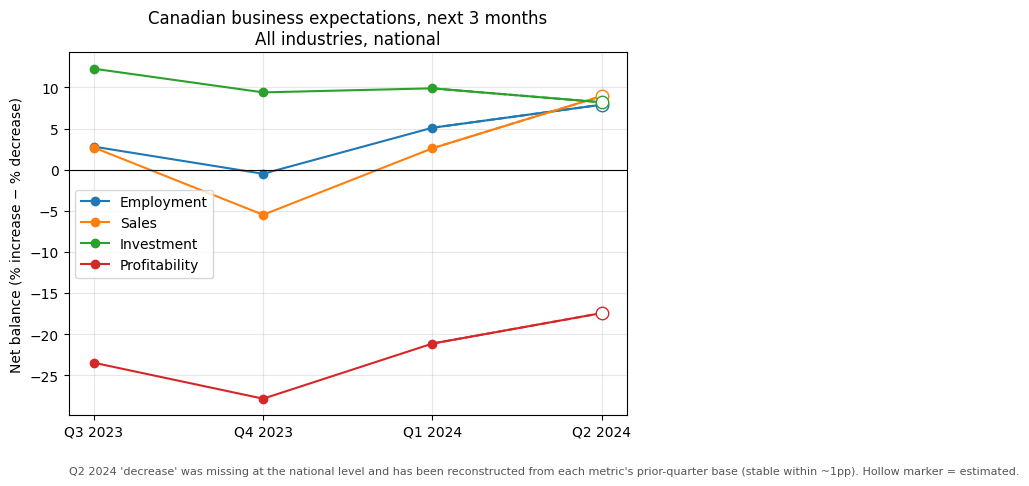

In [15]:
import matplotlib.pyplot as plt

TOTAL_IND = [c for c in cells["Business_characteristics"].unique() if c.startswith("North American")][0]
QORDER = ["Q3 2023", "Q4 2023", "Q1 2024", "Q2 2024"]

nat = cells[(cells["GEO"] == "Canada") & (cells["Business_characteristics"] == TOTAL_IND)].copy()

# Q2 'decrease' is missing nationally. Reconstruct from the prior-quarter base,
# which is stable to within ~1pp per metric.
prior_base = nat[nat["Quarter"] != "Q2 2024"].groupby("metric")["base"].mean()
fix = nat["Quarter"].eq("Q2 2024") & nat["pct_decrease"].isna()
nat.loc[fix, "pct_decrease"] = (
    nat.loc[fix, "metric"].map(prior_base)
    - nat.loc[fix, "pct_increase"]
    - nat.loc[fix, "pct_same"]
)
nat["base"] = nat[["pct_increase", "pct_same", "pct_decrease"]].sum(axis=1)
nat["net_balance"] = 100 * (nat["pct_increase"] - nat["pct_decrease"]) / nat["base"]

wide = nat.pivot(index="Quarter", columns="metric", values="net_balance").reindex(QORDER)
print(wide.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
imputed_q = "Q2 2024"
i = list(wide.index).index(imputed_q)

for m in ["Employment", "Sales", "Investment", "Profitability"]:
    y = wide[m].values
    line, = ax.plot(wide.index[:i+1], y[:i+1], marker="o", label=m)
    c = line.get_color()
    # Dashed connector into the estimated point (no markers of its own)
    ax.plot(wide.index[i-1:i+1], y[i-1:i+1], ls="--", color=c, lw=1.5)
    # Hollow marker on the estimated point only
    ax.plot([wide.index[i]], [y[i]], marker="o", color=c,
            markerfacecolor="white", markersize=9, ls="none")

ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Net balance (% increase − % decrease)")
ax.set_title("Canadian business expectations, next 3 months\nAll industries, national")
ax.legend(loc="center left")
ax.grid(alpha=0.3)
ax.text(0.0, -0.14,
        "Q2 2024 'decrease' was missing at the national level and has been reconstructed "
        "from each metric's prior-quarter base (stable within ~1pp). Hollow marker = estimated.",
        transform=ax.transAxes, fontsize=8, color="#555", va="top")
plt.tight_layout()
plt.savefig("outputs/analysis1_national_trend.png", dpi=150, bbox_inches="tight")
plt.show()

13 industries shown; national benchmark -17.4
                       Business_characteristics  net_balance  share_same
     Agriculture, forestry, fishing and hunting        -41.0        45.9
                Accommodation and food services        -30.1        41.5
                 Transportation and warehousing        -27.9        45.8
              Health care and social assistance        -23.5        64.1
                                   Retail trade        -18.4        52.4
             Real estate and rental and leasing        -16.5        61.2
                                Wholesale trade        -16.1        53.3
  Mining, quarrying, and oil and gas extraction        -14.4        61.4
                                  Manufacturing        -11.1        49.9
Professional, scientific and technical services        -10.9        55.2
             Arts, entertainment and recreation         -8.8        58.9
                                   Construction         -8.2        61.6
     

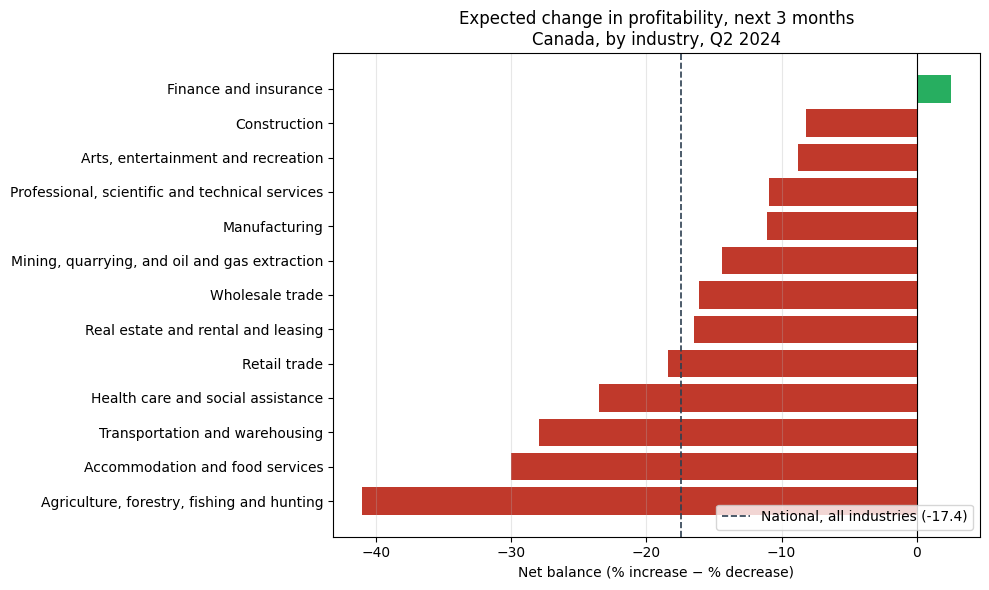

In [16]:
# Latest quarter, national, by industry — who is bearing the profitability squeeze?
ind = cells[
    (cells["GEO"] == "Canada")
    & (cells["Quarter"] == "Q2 2024")
    & (cells["metric"] == "Profitability")
    & (cells["Business_characteristics"] != TOTAL_IND)
    & (cells["n_missing"] == 0)
    & (cells["n_zero"] == 0)
].copy()

ind = ind.sort_values("net_balance")
benchmark = wide.loc["Q2 2024", "Profitability"]  

print(f"{len(ind)} industries shown; national benchmark {benchmark:.1f}")
print(ind[["Business_characteristics", "net_balance", "share_same"]].round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in ind["net_balance"]]
ax.barh(ind["Business_characteristics"], ind["net_balance"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.axvline(benchmark, color="#2c3e50", ls="--", lw=1.2,
           label=f"National, all industries ({benchmark:.1f})")
ax.set_xlabel("Net balance (% increase − % decrease)")
ax.set_title("Expected change in profitability, next 3 months\nCanada, by industry, Q2 2024")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/analysis2_industry_profitability.png", dpi=150)
plt.show()

In [17]:
%%writefile src/ingest.py
"""Ingest a new quarterly CSBC file and refresh the national trend chart.

Usage:
    python src/ingest.py data/raw/"Data CSBC-Q3 2024.csv"
    python src/ingest.py            # rebuild from everything in data/raw/
"""
import sys
import glob
from pathlib import Path

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parent.parent
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed" / "combined.csv"
OUTPUT = ROOT / "outputs" / "analysis1_national_trend.png"

REQUIRED = ["GEO", "Business_characteristics", "Business_information",
            "Expected_change", "VALUE", "Quarter"]

DIRECTION_ALIASES = {
    "increase": "increase",
    "stay about the same": "stay about the same",
    "stay the same": "stay about the same",
    "decrease": "decrease",
}
METRIC_ALIASES = {
    "employment": "Employment", "sales": "Sales",
    "profitability": "Profitability",
    "investment": "Investment", "capital investment": "Investment",
}


def read_quarter(path):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    missing = [c for c in REQUIRED if c not in df.columns]
    if missing:
        raise ValueError(f"{Path(path).name}: missing column(s) {missing}")

    df["direction"] = df["Expected_change"].str.strip().str.lower().map(DIRECTION_ALIASES)
    df["metric"] = df["Business_information"].str.strip().str.lower().map(METRIC_ALIASES)

    for col, src in [("direction", "Expected_change"), ("metric", "Business_information")]:
        bad = sorted(df.loc[df[col].isna(), src].unique())
        if bad:
            raise ValueError(f"{Path(path).name}: unrecognised {src} value(s) {bad}")

    df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")
    return df[REQUIRED + ["direction", "metric"]]


def build_combined(new_file=None):
    if new_file:
        frames = [read_quarter(PROCESSED)] if PROCESSED.exists() else []
        frames.append(read_quarter(new_file))
    else:
        frames = [read_quarter(p) for p in sorted(glob.glob(str(RAW / "*.csv")))]

    combined = pd.concat(frames, ignore_index=True)
    combined = combined.drop_duplicates(
        ["GEO", "Business_characteristics", "metric", "direction", "Quarter"], keep="last"
    )
    PROCESSED.parent.mkdir(parents=True, exist_ok=True)
    combined.to_csv(PROCESSED, index=False)
    return combined


def to_cells(long_df):
    cells = (
        long_df.pivot_table(
            index=["GEO", "Business_characteristics", "metric", "Quarter"],
            columns="direction", values="VALUE", aggfunc="first", dropna=False,
        ).reset_index()
        .rename(columns={"increase": "pct_increase",
                         "stay about the same": "pct_same",
                         "decrease": "pct_decrease"})
    )
    parts = cells[["pct_increase", "pct_same", "pct_decrease"]]
    cells["base"] = parts.sum(axis=1, skipna=True)
    cells["n_missing"] = parts.isna().sum(axis=1)
    return cells


def qkey(q):
    n, y = q.split(" ")
    return (int(y), int(n[1]))


def national_trend(cells):
    total = [c for c in cells["Business_characteristics"].unique()
             if c.startswith("North American")][0]
    nat = cells[(cells["GEO"] == "Canada")
                & (cells["Business_characteristics"] == total)].copy()

    order = sorted(nat["Quarter"].unique(), key=qkey)

    # Reconstruct a missing 'decrease' in ANY quarter, not only the newest one:
    # a quarter stops being "latest" as soon as the next file arrives.
    complete_base = nat[nat["n_missing"] == 0].groupby("metric")["base"].mean()
    fix = nat["pct_decrease"].isna() & nat["metric"].map(complete_base).notna()
    if fix.any():
        nat.loc[fix, "pct_decrease"] = (
            nat.loc[fix, "metric"].map(complete_base)
            - nat.loc[fix, "pct_increase"] - nat.loc[fix, "pct_same"]
        )
        for q in sorted(nat.loc[fix, "Quarter"].unique(), key=qkey):
            n = int((fix & nat["Quarter"].eq(q)).sum())
            print(f"[info] reconstructed {n} missing 'decrease' value(s) in {q}")

    nat["base"] = nat[["pct_increase", "pct_same", "pct_decrease"]].sum(axis=1)
    nat["net_balance"] = 100 * (nat["pct_increase"] - nat["pct_decrease"]) / nat["base"]

    wide = nat.pivot(index="Quarter", columns="metric", values="net_balance").reindex(order)

    fig, ax = plt.subplots(figsize=(9, 5))
    for m in wide.columns:
        ax.plot(wide.index, wide[m], marker="o", label=m)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Net balance (% increase − % decrease)")
    ax.set_title("Canadian business expectations, next 3 months\nAll industries, national")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUTPUT, dpi=150)
    return wide


if __name__ == "__main__":
    new_file = sys.argv[1] if len(sys.argv) > 1 else None
    combined = build_combined(new_file)
    print(f"[info] combined dataset: {len(combined)} rows, "
          f"{combined['Quarter'].nunique()} quarters -> {PROCESSED}")
    wide = national_trend(to_cells(combined))
    print(wide.round(1))
    print(f"[info] chart written to {OUTPUT}")

Overwriting src/ingest.py
